In [1]:
# Deactivate distracting warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from data_processing import display_data_summary, load_event_data
from visualization import load_data, plot_event_count, plot_kde, plot_goal_positions

In [3]:
# Define the path to the dataset
path = "../data/"

In [4]:
# Display Data Summary. Note that executing this code can take several minutes due the complexity of the parsing routines.
display_data_summary(path)

Unique player IDs: 207
Unique teams: 10
Total number of events: 11137
Unique event ID counts:
 Play_Pass                            5241
OtherBallAction                      1699
TacklingGame                         1412
Delete                               1074
ThrowIn_Play_Pass                     281
BallClaiming                          206
Foul                                  160
FreeKick_Play_Pass                    156
Play_Cross                            140
OutSubstitution                       128
GoalKick_Play_Pass                    119
ShotAtGoal_ShotWide                    63
CornerKick_Play_Cross                  53
ShotAtGoal_SavedShot                   41
Caution                                37
ShotAtGoal_BlockedShot                 37
KickOff_Play_Pass                      32
RefereeBall                            30
FinalWhistle                           28
ThrowIn_Play_Cross                     24
PenaltyNotAwarded                      18
VideoAssistantAction   

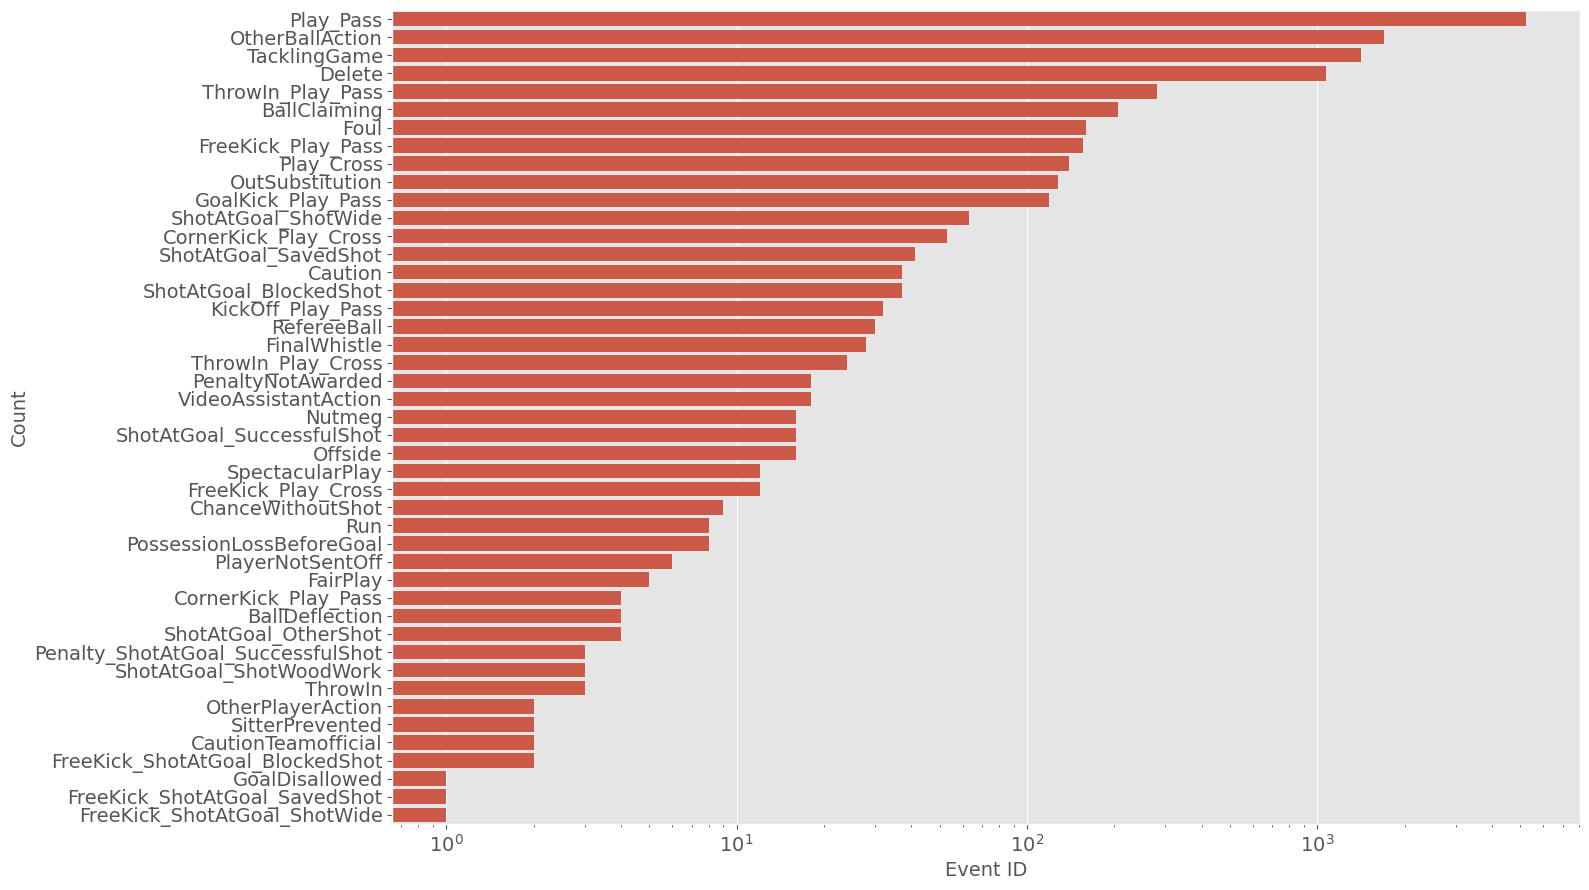

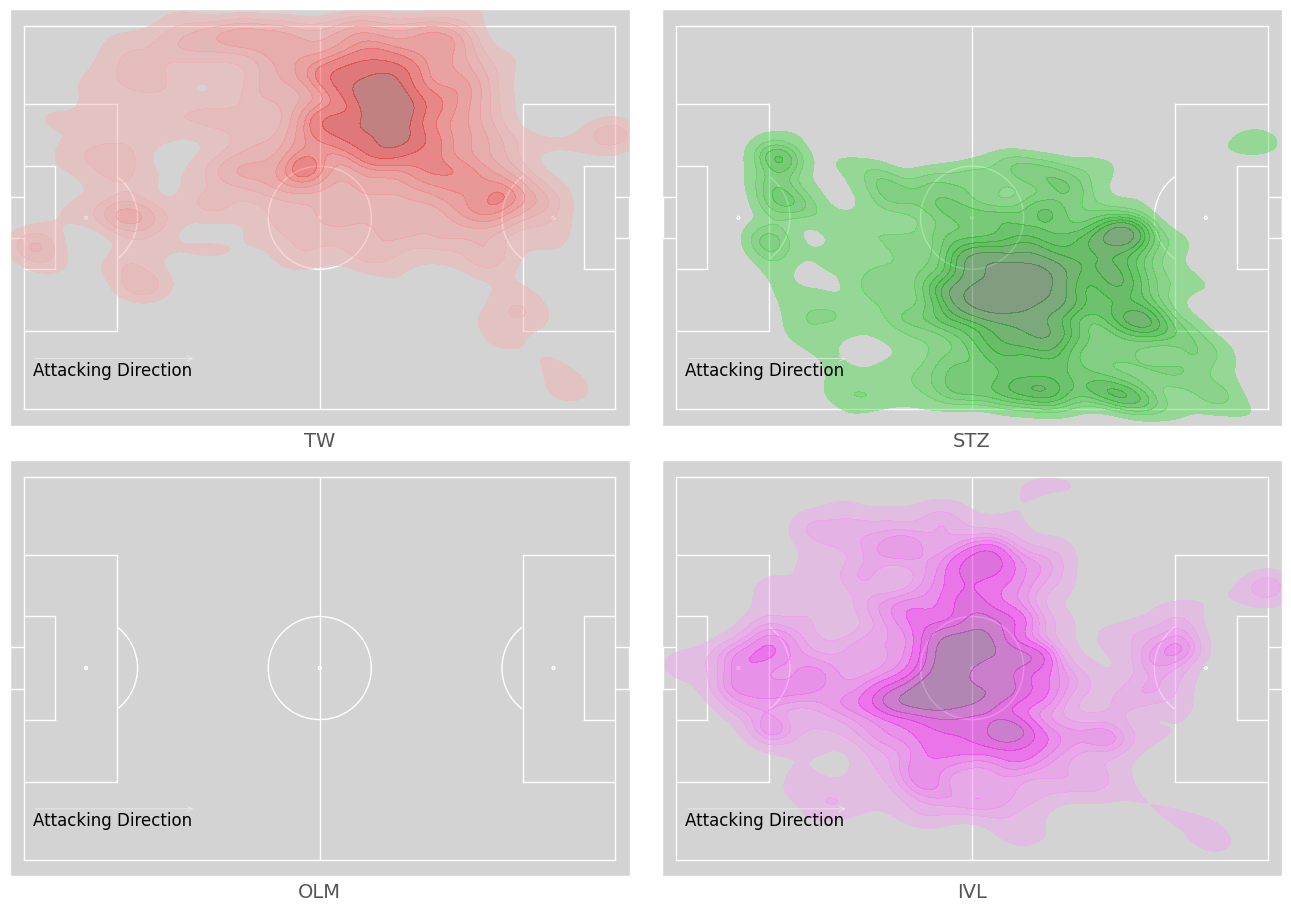

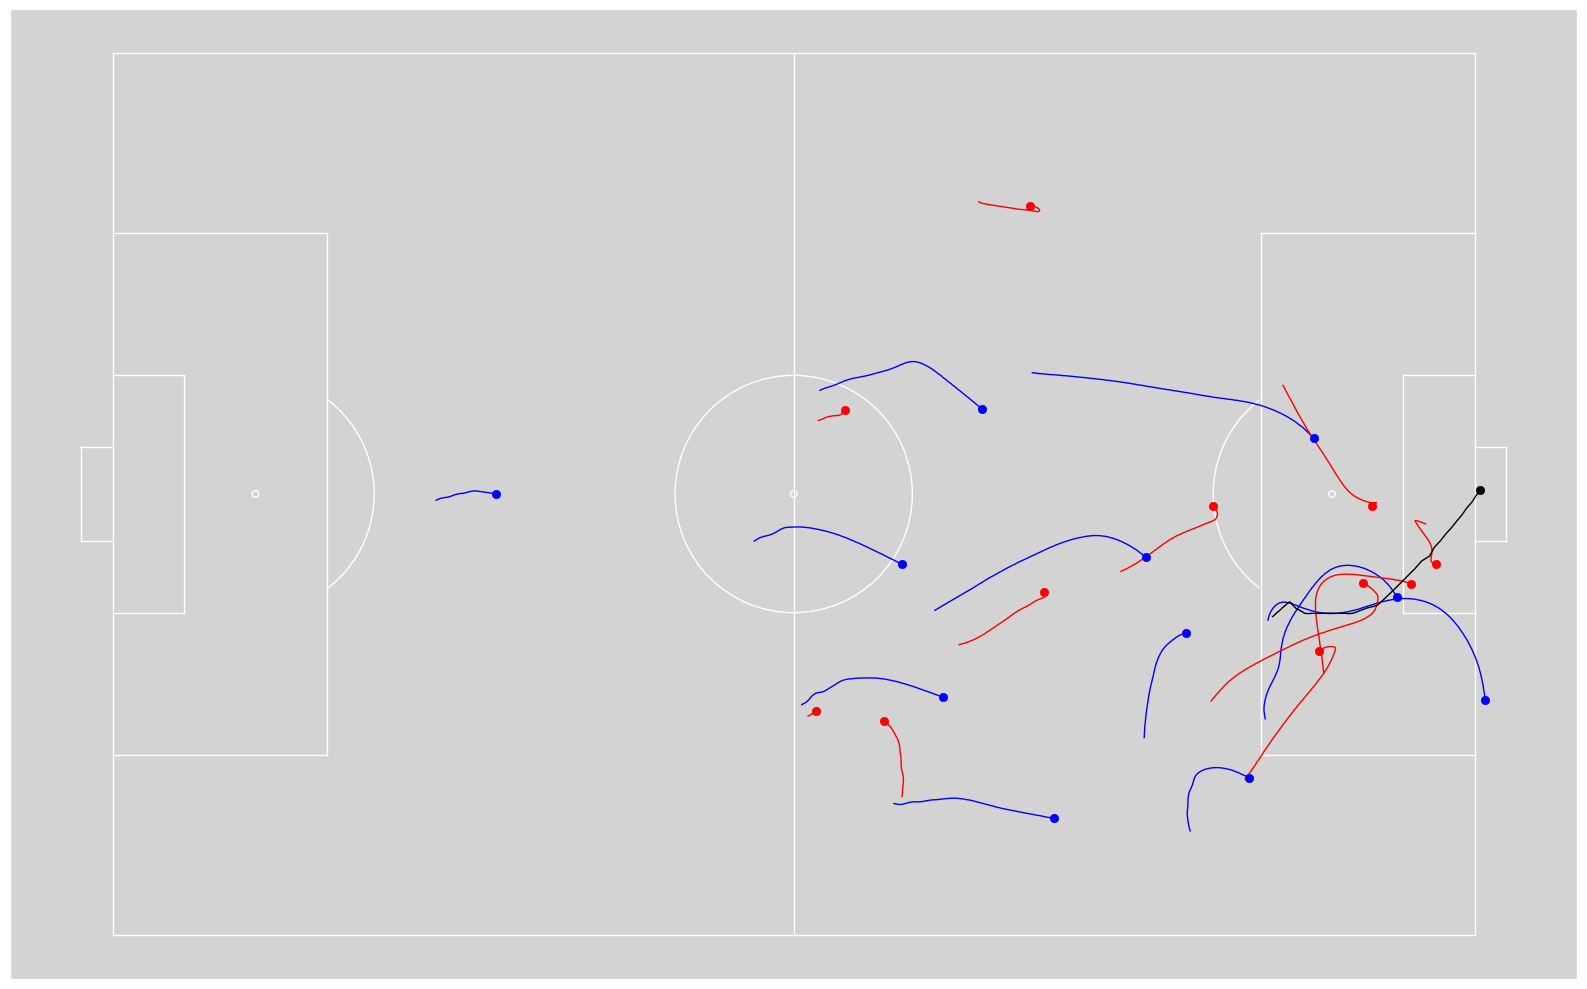

In [35]:
# 1. Define your variable (everything after "DFL-COM-" and before ".xml")
# Match00 - 000002_DFL-MAT-J03WOH
# Match01 - 000001_DFL-MAT-J03WN1
# Match02 - 000001_DFL-MAT-J03WMX
# Match03 - 000002_DFL-MAT-J03WR9
# Match04 - 000002_DFL-MAT-J03WPY
# Match05 - 000002_DFL-MAT-J03WQQ
# Match06 - 000002_DFL-MAT-J03WOY

match_id = "000002_DFL-MAT-J03WOY"

# 2. Use f-strings to inject the variable directly into the filenames
file_name_pos = f"DFL_04_03_positions_raw_observed_DFL-COM-{match_id}.xml"
file_name_infos = f"DFL_02_01_matchinformation_DFL-COM-{match_id}.xml"
file_name_events = f"DFL_03_02_events_raw_DFL-COM-{match_id}.xml"

# Load data
xy_objects, events, pitch = load_data(path, file_name_pos, file_name_infos, file_name_events)
all_events = load_event_data(path)

# Plot Event Count
plot_event_count(all_events)

# Plot KDE
plot_kde(xy_objects, pitch)

# Plot Goal Positions
plot_goal_positions(xy_objects, events, pitch)

In [36]:

first_half=xy_objects['firstHalf']
second_half=xy_objects['secondHalf']

first_half_home = first_half['Home']
first_half_away = first_half['Away']
first_half_ball = first_half['Ball']

second_half_home = second_half['Home']
second_half_away = second_half['Away']
second_half_ball = second_half['Ball']

In [37]:
print(first_half_home.xy)

[[   nan    nan -15.26 ...    nan    nan    nan]
 [   nan    nan -15.3  ...    nan    nan    nan]
 [   nan    nan -15.34 ...    nan    nan    nan]
 ...
 [   nan    nan  -3.57 ...    nan    nan    nan]
 [   nan    nan  -3.57 ...    nan    nan    nan]
 [   nan    nan  -3.59 ...    nan    nan    nan]]


In [38]:
print(first_half_away.xy)

[[   nan    nan -49.55 ...  -5.01    nan    nan]
 [   nan    nan -49.54 ...  -5.03    nan    nan]
 [   nan    nan -49.52 ...  -5.07    nan    nan]
 ...
 [   nan    nan -48.37 ...    nan    nan    nan]
 [   nan    nan -48.47 ...    nan    nan    nan]
 [   nan    nan -48.57 ...    nan    nan    nan]]


In [39]:
print(first_half_ball.xy)

[[ -5.34  -0.02]
 [ -6.13  -0.06]
 [ -6.84  -0.1 ]
 ...
 [-16.99  -4.76]
 [-16.99  -4.76]
 [-16.99  -4.76]]


In [40]:
import numpy as np

# 1. Extract the raw NumPy arrays from the Floodlight XY objects using the .xy attribute
# (Assuming your objects are named exactly as you typed them)
fh_home_array = first_half_home.xy
fh_away_array = first_half_away.xy
fh_ball_array = first_half_ball.xy

sh_home_array = second_half_home.xy
sh_away_array = second_half_away.xy
sh_ball_array = second_half_ball.xy

# 2. Save everything into a single, compressed .npz file
# You can name the internal keys whatever you want (e.g., 'fh_home')
np.savez_compressed(
    'match_tracking_data.npz', 
    fh_home=fh_home_array,
    fh_away=fh_away_array,
    fh_ball=fh_ball_array,
    sh_home=sh_home_array,
    sh_away=sh_away_array,
    sh_ball=sh_ball_array
)

print("Data successfully saved to match_tracking_data.npz!")

Data successfully saved to match_tracking_data.npz!
